In [2]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.neural_network import MLPRegressor
from sklearn.preprocessing import StandardScaler

当X为50000000时，预测的Y值为：11.510146373369265


/home/zyq0416/workspace/CaL/.venv/lib/python3.10/site-packages/matplotlib/backends/backend_agg.py:238: RuntimeWarning: Glyph 19982 missing from current font.
  font.set_text(s, 0.0, flags=flags)
/home/zyq0416/workspace/CaL/.venv/lib/python3.10/site-packages/matplotlib/backends/backend_agg.py:238: RuntimeWarning: Glyph 30340 missing from current font.
  font.set_text(s, 0.0, flags=flags)
/home/zyq0416/workspace/CaL/.venv/lib/python3.10/site-packages/matplotlib/backends/backend_agg.py:238: RuntimeWarning: Glyph 20851 missing from current font.
  font.set_text(s, 0.0, flags=flags)
/home/zyq0416/workspace/CaL/.venv/lib/python3.10/site-packages/matplotlib/backends/backend_agg.py:238: RuntimeWarning: Glyph 31995 missing from current font.
  font.set_text(s, 0.0, flags=flags)
/home/zyq0416/workspace/CaL/.venv/lib/python3.10/site-packages/matplotlib/backends/backend_agg.py:238: RuntimeWarning: Glyph 39044 missing from current font.
  font.set_text(s, 0.0, flags=flags)
/home/zyq0416/workspace/C

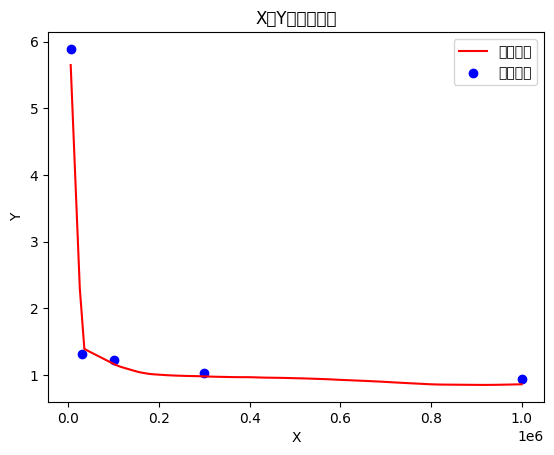

In [4]:
# 初始化输入和输出数据
X = np.array([[5000], [30000], [100000], [300000], [1000000]]).astype(float)  # 输入数据需转换为二维数组
Y = np.array([5.89, 1.31, 1.22, 1.03, 0.94]).astype(float)  # 输出数据
#Y = np.array([9.66, 3.05, 1.65, 1.40, 1.27]).astype(float)  # 输出数据
 
# 数据标准化处理，这有助于提升神经网络的训练效果
scaler_X = StandardScaler()
scaler_Y = StandardScaler()
X_scaled = scaler_X.fit_transform(X)
Y_scaled = scaler_Y.fit_transform(Y.reshape(-1, 1)).flatten()
 
# 构建并训练神经网络模型，增加alpha参数以防止过拟合
mlp = MLPRegressor(hidden_layer_sizes=(200, 200), max_iter=1000, alpha=0.01, random_state=1)
mlp.fit(X_scaled, Y_scaled)
 
# 定义一个类来预测给定X值的Y值
class NeuralNetworkPredictor:
    def __init__(self, model, scaler_X, scaler_Y):
        self.model = model
        self.scaler_X = scaler_X
        self.scaler_Y = scaler_Y
 
    def predict(self, X):
        X_scaled = self.scaler_X.transform(X.reshape(-1, 1))
        Y_scaled_pred = self.model.predict(X_scaled)
        Y_pred = self.scaler_Y.inverse_transform(Y_scaled_pred.reshape(-1, 1))
        return Y_pred.flatten()
 
# 实例化预测类
predictor = NeuralNetworkPredictor(mlp, scaler_X, scaler_Y)
 
# 预测示例X值（如5000）对应的Y值
X_example = np.array([[50000000]])
Y_pred_example = predictor.predict(X_example)
print(f"当X为{X_example[0][0]}时，预测的Y值为：{Y_pred_example[0]}")
 
# 绘制预测结果与真实数据点的对比图
X_all = np.linspace(min(X), max(X), 100).reshape(-1, 1)
Y_pred_all = predictor.predict(X_all)
 
plt.scatter(X, Y, color='blue', label='真实数据')
plt.plot(X_all, Y_pred_all, color='red', label='预测结果')
plt.xlabel('X')
plt.ylabel('Y')
plt.title('X与Y的关系预测')
plt.legend()
plt.show()